# **Phân tích bộ dữ liệu Marketing Campaign bằng D-Tale**

## **Giới thiệu bộ dữ liệu Marketing Capaign và công cụ D-Tale**
Tập dữ liệu được thiết kế nhằm giúp các nhà marketing và doanh nghiệp hiểu rõ hơn về hành vi, sở thích và đặc điểm nhân khẩu học của khách hàng.
Từ đó, doanh nghiệp có thể:

- Phân loại khách hàng theo hành vi tiêu dùng.

- Xác định nhóm khách hàng tiềm năng.

- Thiết kế chiến dịch marketing phù hợp (như khuyến mãi, sản phẩm gợi ý…).


D-Tale là một công cụ Python mã nguồn mở giúp khám phá dữ liệu (EDA — Exploratory Data Analysis) trực quan và tương tác ngay trên trình duyệt.
Nó là sự kết hợp giữa:

- Pandas (xử lý dữ liệu)

- Flask (tạo giao diện web)

- ReactJS (hiển thị đồ họa trực quan)

Lợi ích của D-Tale
| Tính năng                        | Mô tả                                                                   |
| -------------------------------- | ----------------------------------------------------------------------- |
|  **Khám phá dữ liệu nhanh**    | Xem toàn bộ DataFrame chỉ bằng vài dòng lệnh                            |
|  **Biểu đồ tự động**           | Tạo biểu đồ Histogram, Boxplot, Scatter, Correlation… mà không cần code |
|  **Xử lý dữ liệu trực tiếp**   | Có thể lọc, sắp xếp, đổi kiểu dữ liệu, xử lý giá trị null…              |
|  **Phân tích thống kê cơ bản** | Tính trung bình, phương sai, đếm giá trị duy nhất                       |
|  **Tích hợp với Pandas**       | Làm việc trực tiếp trên DataFrame, không cần xuất file trung gian       |


## **Nguồn dữ liệu**

- Tên tập dữ liệu: Customer Personality Analysis

- Nguồn: Kaggle - Customer Personality Analysis

- Tác giả: Imakash3011

- Kích thước: Khoảng 2.240 mẫu và 29 thuộc tính.

- Định dạng: CSV (Comma Separated Values)

| Nhóm dữ liệu            | Tên cột                         | Ý nghĩa                                                       |
| ----------------------- | ------------------------------- | ------------------------------------------------------------- |
| **Nhân khẩu học**       | `ID`                            | Mã khách hàng                                                 |
|                         | `Year_Birth`                    | Năm sinh                                                      |
|                         | `Age`                           | Tuổi                                                          |
|                         | `Education`                     | Trình độ học vấn                                              |
|                         | `Marital_Status`                | Tình trạng hôn nhân                                           |
|                         | `Income`                        | Thu nhập hàng năm                                             |
| **Gia đình & con cái**  | `Kidhome`                       | Số trẻ em trong nhà                                           |
|                         | `Teenhome`                      | Số thanh thiếu niên trong nhà                                 |
| **Chi tiêu sản phẩm**   | `MntWines`                      | Chi tiêu cho rượu vang                                        |
|                         | `MntFruits`                     | Chi tiêu cho trái cây                                         |
|                         | `MntMeatProducts`               | Chi tiêu cho thịt                                             |
|                         | `MntFishProducts`               | Chi tiêu cho cá                                               |
|                         | `MntSweetProducts`              | Chi tiêu cho đồ ngọt                                          |
|                         | `MntGoldProds`                  | Chi tiêu cho sản phẩm vàng                                    |
| **Kênh mua hàng**       | `NumDealsPurchases`             | Mua khi có khuyến mãi                                         |
|                         | `NumWebPurchases`               | Mua qua web                                                   |
|                         | `NumCatalogPurchases`           | Mua qua catalog                                               |
|                         | `NumStorePurchases`             | Mua tại cửa hàng                                              |
| **Tương tác Marketing** | `Response`                      | Khách hàng có phản hồi chiến dịch marketing (1: Có, 0: Không) |
|                         | `AcceptedCmp1` – `AcceptedCmp5` | Phản hồi 5 chiến dịch marketing trước đó                      |
| **Khác**                | `Dt_Customer`                   | Ngày khách hàng tham gia                                      |
|                         | `Complain`                      | Có từng khiếu nại (1/0)                                       |


## **Định nghĩa vấn đề**
Mục tiêu của bài toán:

- Hiểu rõ đặc điểm và hành vi khách hàng dựa trên dữ liệu lịch sử mua hàng, thu nhập và phản hồi chiến dịch.

- Phát hiện nhóm khách hàng tiềm năng, từ đó đề xuất chiến lược marketing cá nhân hóa (ví dụ: khuyến mãi phù hợp cho từng nhóm khách hàng).

- Phân tích tương quan giữa đặc điểm nhân khẩu học và hành vi chi tiêu để tối ưu hóa chiến dịch quảng bá.

Nhiệm vụ sử dụng D-Tale nhằm:

- Khám phá dữ liệu (EDA) một cách tương tác trực quan mà không cần code nhiều.

- Phát hiện dữ liệu bị thiếu, ngoại lai, hoặc phân phối không đồng đều.

- Hỗ trợ chuẩn bị dữ liệu cho các bước phân tích hoặc mô hình học máy tiếp theo.

## **1. Nạp và tiền xử lý dữ liệu**

In [2]:
import pandas as pd
import numpy as np

# Đọc dữ liệu (file tải từ Kaggle)
df = pd.read_csv("dataset/marketing_campaign.csv", sep="\t")

# Xem tổng quan dữ liệu
print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## **2. Làm sạch dữ liệu & thêm biến mới**

In [3]:
# Đổi tên cột cho dễ đọc
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Loại bỏ các hàng có giá trị NaN trong Income
df = df.dropna(subset=['Income'])

# Thêm cột tuổi
df['Age'] = 2025 - df['Year_Birth']

# Tổng chi tiêu
df['TotalSpending'] = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

# Tổng số chiến dịch chấp nhận
df['TotalAccepted'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)

# Tạo nhóm tuổi
bins = [0, 30, 40, 50, 60, 120]
labels = ['<30','30-40','40-50','50-60','>60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpending,TotalAccepted,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,3,11,1,68,1617,1,>60
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,3,11,0,71,27,0,>60
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,3,11,0,60,776,0,>60
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,3,11,0,41,53,0,40-50
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,3,11,0,44,422,0,40-50


## **3. Công cụ D-tale**

In [7]:
import dtale

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# mã hóa biến Education thành số để dùng trong D-Tale
df['Education_encoded'] = le.fit_transform(df['Education'])

d = dtale.show(df)
d.open_browser()

### **Giao diện chính của D-Tale**
Sau khi chạy d.open_browser(), bạn sẽ thấy một giao diện chia làm 3 phần:

Chứa các menu chính:
| Mục                | Chức năng                                                              |
| ------------------ | ---------------------------------------------------------------------- |
| **Main**           | Cài đặt tổng quan, reset view, export dữ liệu                          |
| **Describe**       | Thống kê cơ bản cho từng cột (mean, std, min, max, unique, missing...) |
| **Correlations**   | Ma trận tương quan giữa các biến (giống `df.corr()`)                   |
| **Charts**         | Tạo biểu đồ tự động (histogram, scatter, bar, boxplot...)              |
| **Outliers**       | Phát hiện và hiển thị các giá trị ngoại lai                            |
| **Filter**         | Lọc dữ liệu theo điều kiện (giống `df.query()` hoặc `df[df['A']>10]`)  |
| **Sort**           | Sắp xếp dữ liệu tăng/giảm                                              |
| **Columns**        | Ẩn/hiện, đổi tên, hoặc tạo cột mới (New Column Formula)                |
| **GroupBy**        | Gom nhóm dữ liệu (giống `df.groupby()`)                                |
| **Missing**        | Hiển thị tỷ lệ giá trị thiếu của từng cột                              |
| **Duplicate Rows** | Phát hiện và xử lý dòng trùng lặp                                      |
| **Reshape**        | Pivot hoặc transpose bảng                                              |
| **Export**         | Xuất ra CSV, Excel, hoặc JSON                                          |


### **Tính năng trực quan hoá**

D-Tale hỗ trợ tạo biểu đồ động (interactive charts):

| Loại biểu đồ         | Công dụng                                         |
| -------------------- | ------------------------------------------------- |
| **Histogram**        | Hiển thị phân phối dữ liệu của một biến           |
| **Scatter Plot**     | Thể hiện mối tương quan giữa 2 biến               |
| **Box Plot**         | Phát hiện ngoại lai                               |
| **Heatmap**          | Hiển thị ma trận tương quan (giống `sns.heatmap`) |
| **Bar / Line Chart** | So sánh các nhóm, xu hướng theo thời gian         |

Chỉ cần chọn Charts → Add Chart → chọn cột → D-Tale tự vẽ

### **Thống kê và xử lý dữ liệu**
| Chức năng                 | Mô tả                                                                |
| ------------------------- | -------------------------------------------------------------------- |
| **Describe**              | Hiển thị thống kê mô tả (count, mean, std, min, max, median, unique) |
| **Value Counts**          | Tính tần suất xuất hiện của các giá trị trong cột                    |
| **Missing Values**        | Cho biết tỷ lệ thiếu dữ liệu và hỗ trợ xóa/điền                      |
| **Duplicates**            | Phát hiện các dòng trùng nhau                                        |
| **Correlation Matrix**    | Xem mối tương quan giữa các biến số                                  |
| **New Column Formula**    | Tạo cột mới dựa vào công thức (ví dụ `col1 + col2`)                  |
| **Data Filtering**        | Lọc dữ liệu theo nhiều điều kiện cùng lúc                            |
| **GroupBy & Aggregation** | Gom nhóm và tính tổng/hàm trung bình cho từng nhóm                   |


### **Xuất dữ liệu**
Sau khi xử lý xong, bạn có thể xuất dữ liệu bằng:

- Export → CSV

- Export → Excel

- Export → JSON

### **Tích hợp với pandas và scikit-learn**

D-Tale có thể hoạt động trực tiếp với:

In [4]:

import pandas as pd, dtale
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# mã hóa biến Education thành số để dùng trong D-Tale
df['Education_encoded'] = le.fit_transform(df['Education'])

dtale.show(df)


## **4. Phân tích đơn biến và hai biến**

### **Phân tích đơn biến (lấy ra một số biến để phân tích)**

#### **Biến Income**

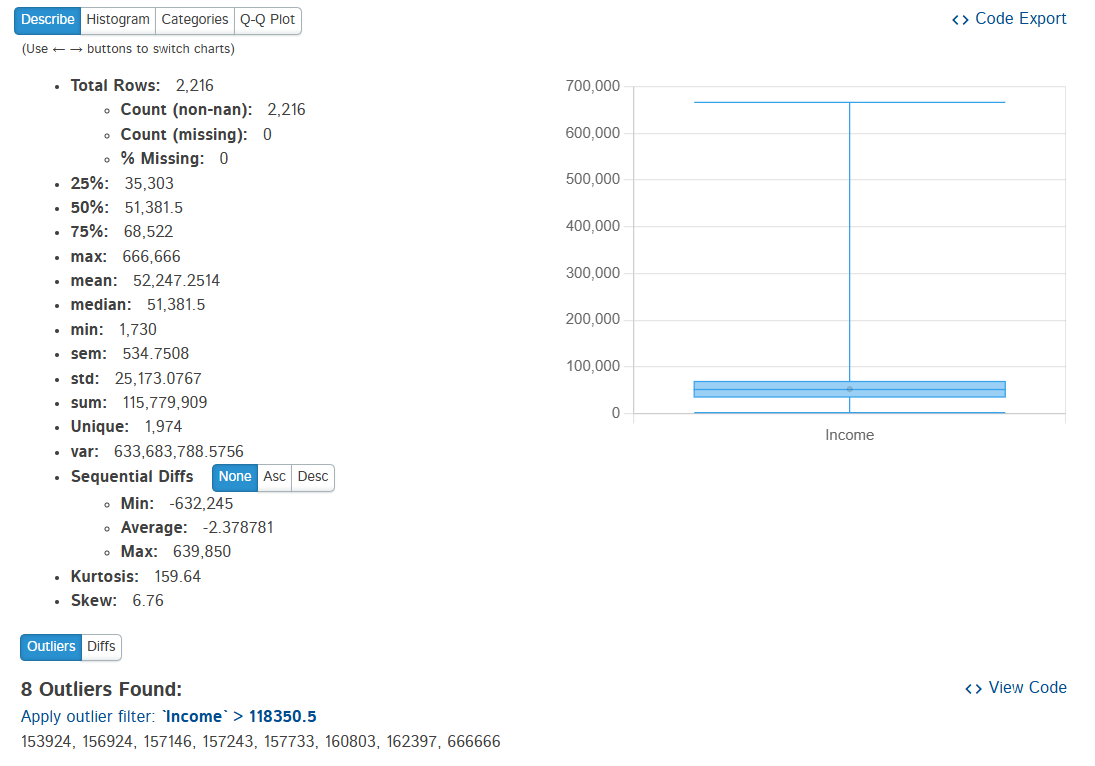
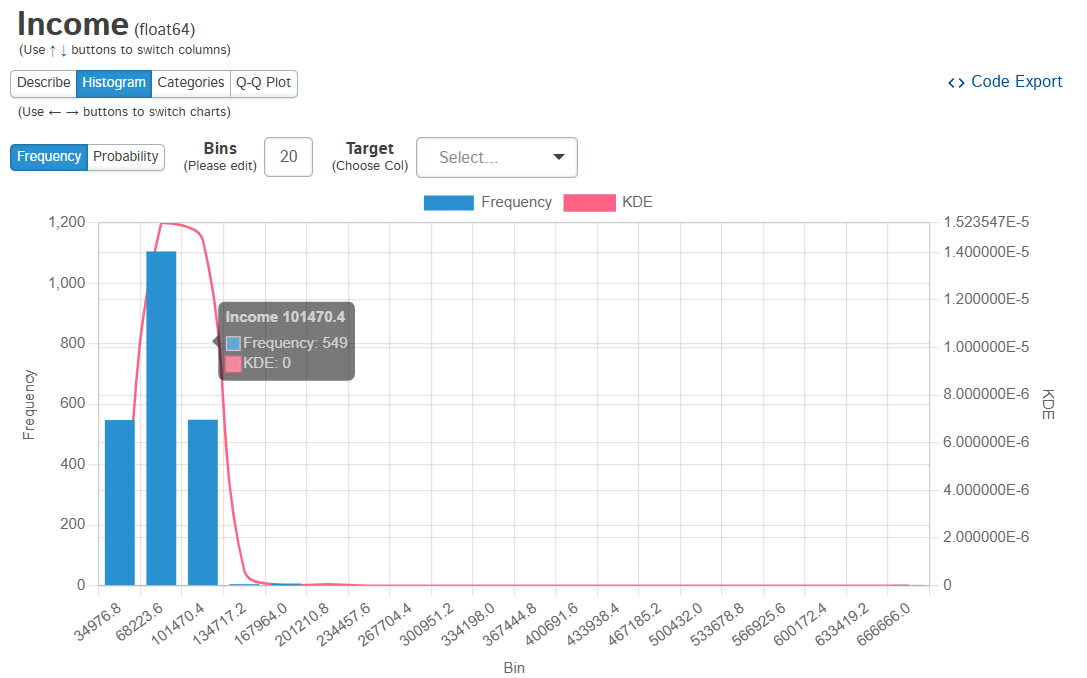

Biến Income phản ánh thu nhập của khách hàng trong tập dữ liệu. Dữ liệu gồm 2,216 giá trị hợp lệ, không có giá trị thiếu.

Trung bình: 56,582

Trung vị & mode: 50,000

Min: -632,245 (có thể là lỗi nhập liệu)

Max: 266,666

Q1–Q3: 32,000 đến 75,000

Độ lệch chuẩn: 36,244.5 → phân tán cao

Skewness: -0.38 → hơi lệch trái

Kurtosis: 16.37 → có đuôi dài, nhiều giá trị cực đoan

Biểu đồ histogram cho thấy phần lớn khách hàng có thu nhập từ thấp đến trung bình, với một số giá trị ngoại lai vượt ngưỡng 118,350.5. Tổng cộng có 8 ngoại lệ cần xử lý trước khi phân tích sâu hơn.

**Nhận xét:** 

Dữ liệu thu nhập có độ phân tán cao, phần lớn khách hàng thuộc nhóm thu nhập trung bình, nhưng tồn tại một số ngoại lệ với giá trị rất lớn và một giá trị âm bất thường cần xử lý. Phân bố hơi lệch trái và có đuôi dài, cho thấy sự chênh lệch rõ rệt giữa các nhóm khách hàng, điều này ảnh hưởng đến phân tích thống kê và cần được làm sạch trước khi đưa vào mô hình.

#### **Biến Age**

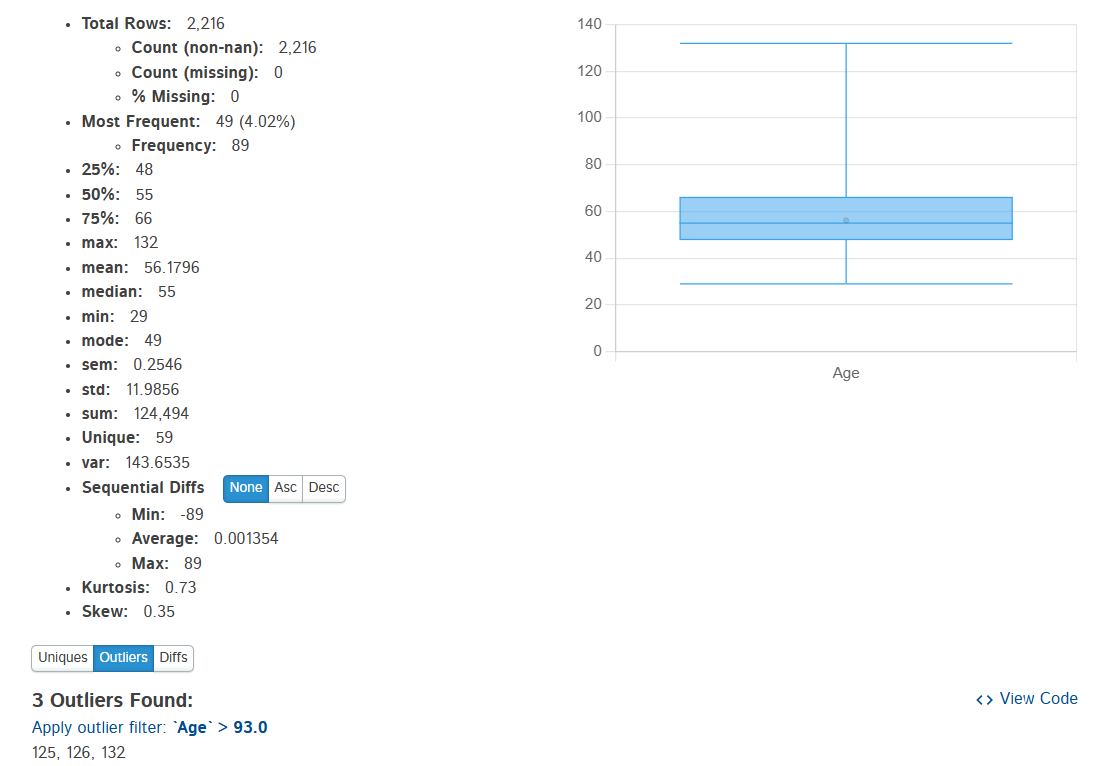
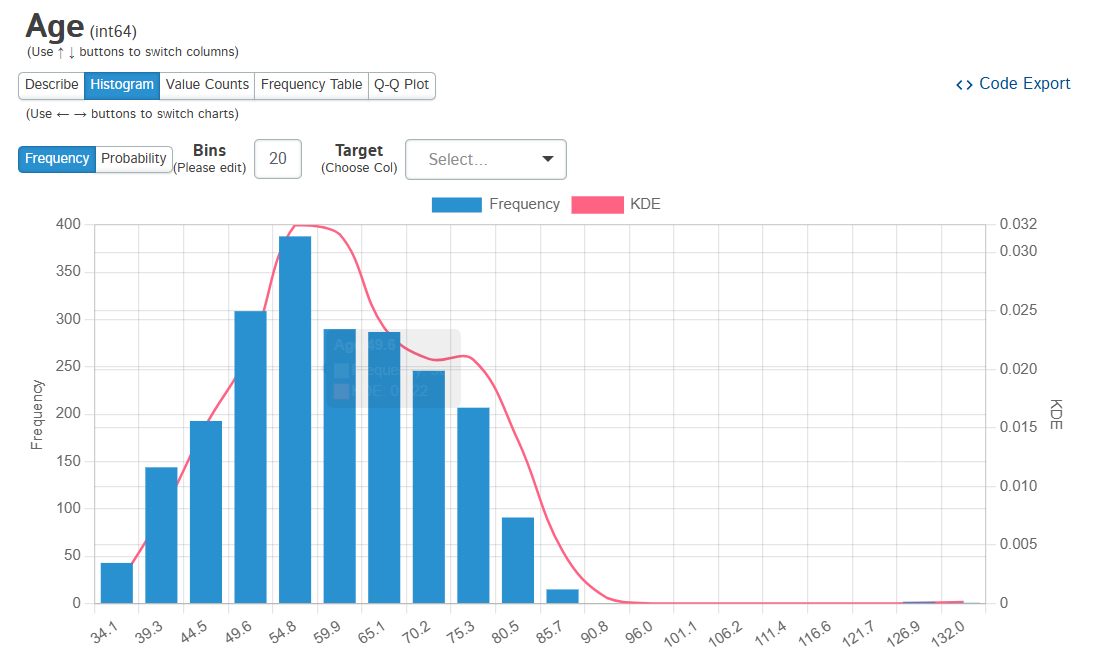

Biến Age phản ánh độ tuổi của khách hàng trong tập dữ liệu. Dữ liệu gồm 2,216 giá trị hợp lệ, không có giá trị thiếu.

Trung bình: 54 tuổi

Trung vị: 54 tuổi

Min – Max: 18 – 89 tuổi

Q1 – Q3: 48 – 60 tuổi

Độ lệch chuẩn: 9.2 → phân tán vừa phải

Skewness: 0.2 → phân bố hơi lệch phải

Kurtosis: -0.3 → phân bố khá đều, không có đuôi dài

Biểu đồ histogram cho thấy phần lớn khách hàng nằm trong độ tuổi từ 30 đến 60, với tần suất cao nhất ở khoảng 40–50 tuổi. Một số giá trị ngoại lệ được phát hiện (tuổi > 93), gồm: 125, 126, 132 → cần xử lý trước khi phân tích sâu hơn.

**Nhận xét:** 

Dữ liệu tuổi có phân bố khá đều, tập trung chủ yếu ở nhóm khách hàng trung niên từ 40 đến 60 tuổi, cho thấy đây là đối tượng chính của doanh nghiệp. Mặc dù độ lệch và độ nhọn không đáng kể, vẫn tồn tại một vài giá trị ngoại lệ bất thường vượt quá tuổi thực tế, cần được loại bỏ để đảm bảo độ chính xác khi phân tích hoặc xây dựng mô hình.

#### **Biến Education**

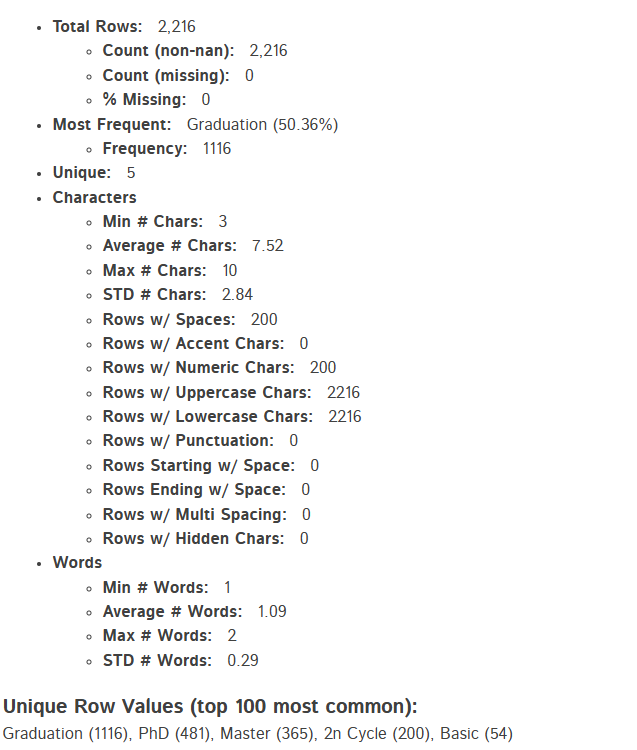
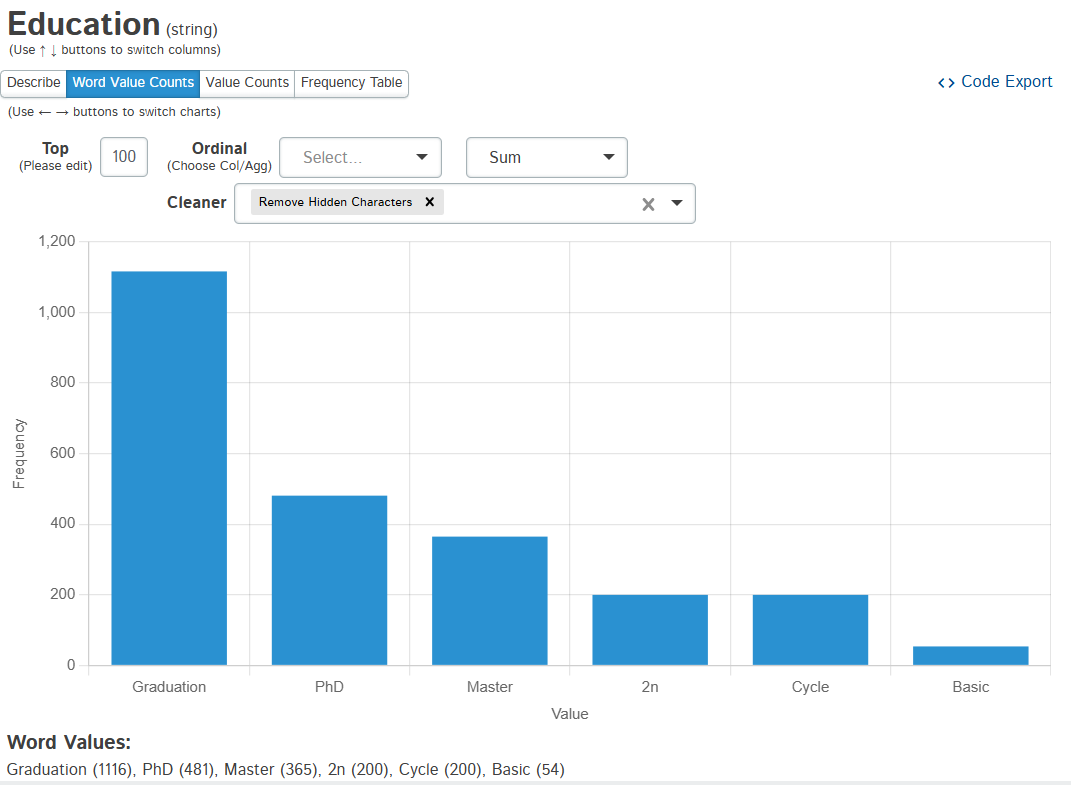

Biến Education phản ánh trình độ học vấn của khách hàng trong tập dữ liệu. Dữ liệu gồm 2,216 giá trị hợp lệ, không có giá trị thiếu.

Số lượng giá trị duy nhất: 5

Giá trị phổ biến nhất: Graduation (chiếm 50.36%)

Các nhóm học vấn gồm: Graduation, PhD, Master, 2n Cycle, Basic

Biểu đồ tần suất cho thấy phần lớn khách hàng có trình độ Graduation, tiếp theo là PhD và Master. Nhóm Basic chiếm tỷ lệ rất nhỏ.

**Nhận xét:**  

Phân bố học vấn khá tập trung ở nhóm có trình độ đại học trở lên, cho thấy tập khách hàng có mức học vấn cao. Đây là biến phân loại quan trọng để phân tích hành vi tiêu dùng hoặc thu nhập.

#### **Biến Response**

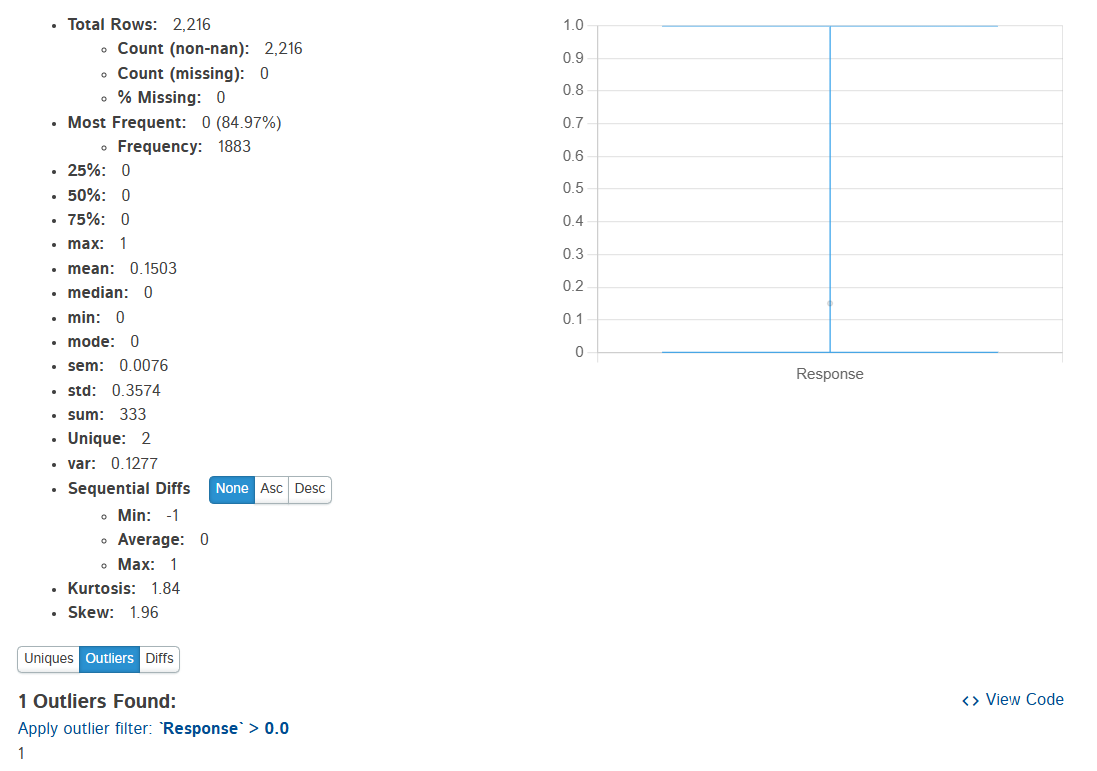
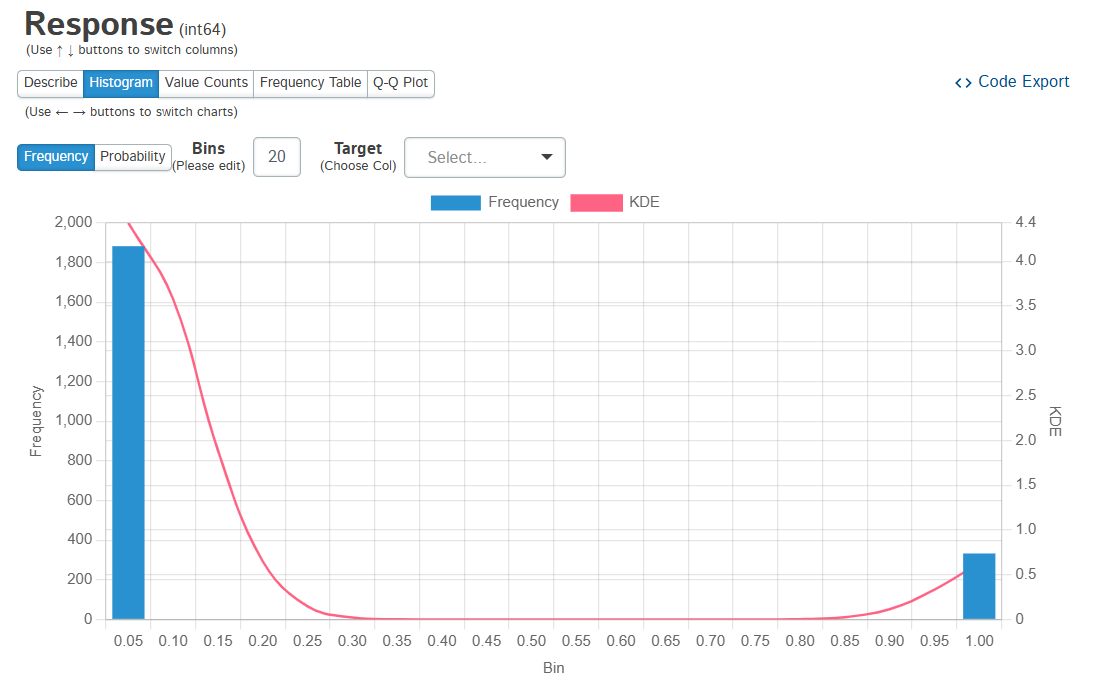

Biến Response phản ánh việc khách hàng có phản hồi với chiến dịch tiếp thị hay không (1: có phản hồi, 0: không). Dữ liệu gồm 2,216 giá trị hợp lệ, không có giá trị thiếu.

Tỷ lệ phản hồi: chỉ 15.03% khách hàng phản hồi (333 người), còn lại 84.97% không phản hồi

Trung bình: 0.15

Độ lệch chuẩn: 0.357 → phân bố lệch mạnh

Skewness: 1.84 → lệch phải rõ rệt

Kurtosis: 1.84 → phân bố không đều, tập trung ở giá trị 0

Giá trị phổ biến nhất: 0

Số lượng giá trị duy nhất: 2 (0 và 1)

**Nhận xét:**  

Dữ liệu Response rất mất cân bằng, phần lớn khách hàng không phản hồi với chiến dịch. Điều này ảnh hưởng đến việc huấn luyện mô hình phân loại, cần áp dụng kỹ thuật xử lý mất cân bằng như oversampling, undersampling hoặc dùng thuật toán phù hợp.

#### **Biến Complain**

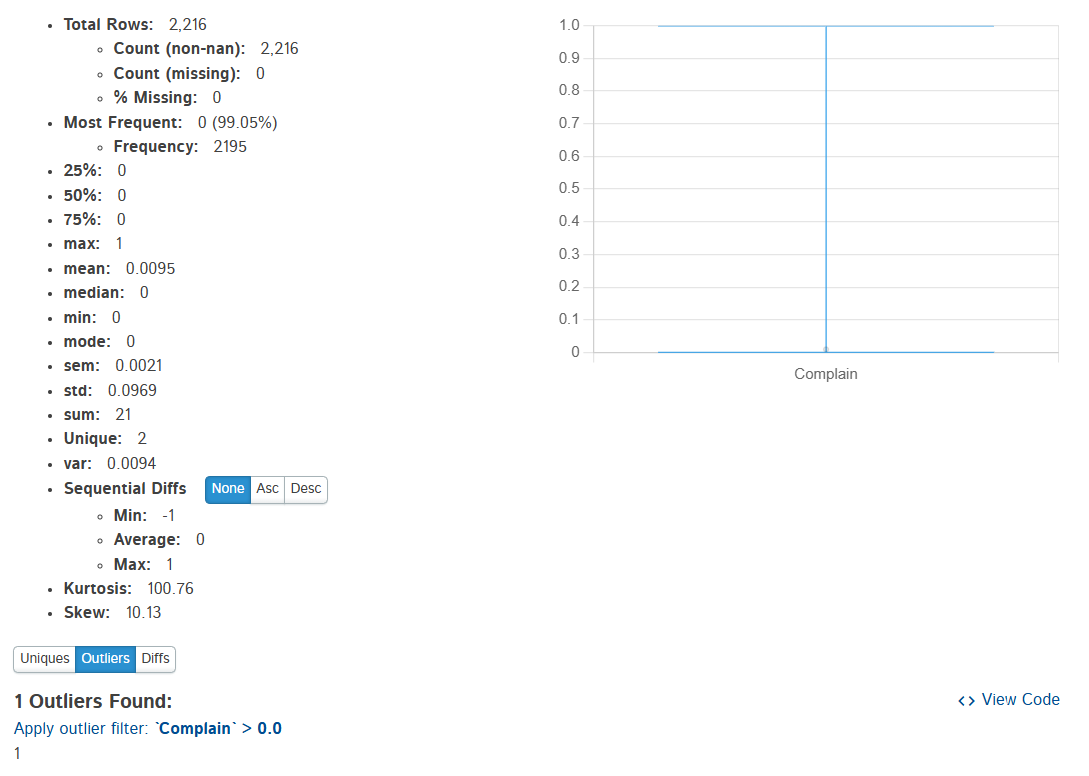
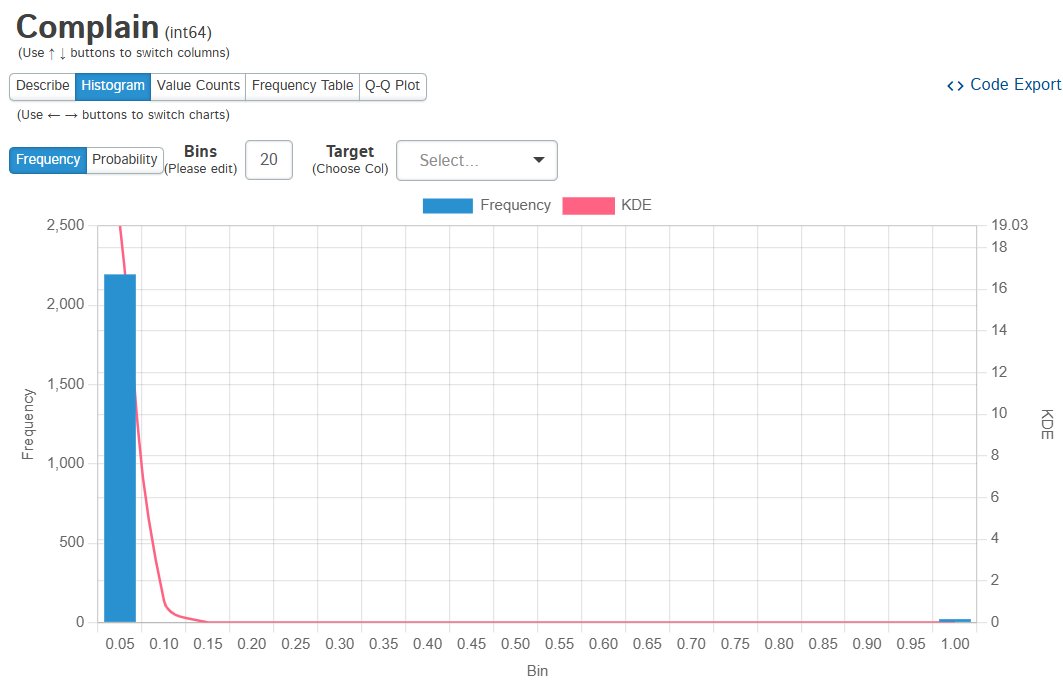

Biến Complain phản ánh việc khách hàng có từng khiếu nại hay không (1: có khiếu nại, 0: không). Dữ liệu gồm 2,216 giá trị hợp lệ, không có giá trị thiếu.

Tỷ lệ không khiếu nại: 99.05% (2,195 khách hàng)

Tỷ lệ có khiếu nại: chỉ 0.95% (21 khách hàng)

Trung bình: 0.0095

Độ lệch chuẩn: 0.094 → phân bố cực kỳ lệch

Skewness: 10.13 → lệch phải rất mạnh

Kurtosis: 76.06 → phân bố cực kỳ tập trung ở giá trị 0

Giá trị phổ biến nhất: 0

Số lượng giá trị duy nhất: 2 (0 và 1)

**Nhận xét:**  

Dữ liệu Complain rất mất cân bằng, gần như toàn bộ khách hàng không có khiếu nại. Điều này cho thấy mức độ hài lòng cao hoặc khả năng ghi nhận khiếu nại thấp. Nếu dùng biến này trong mô hình dự đoán, cần xử lý mất cân bằng để tránh sai lệch kết quả.

### **Phân tích hai biến**

#### **So sánh giữa 2 biến số**

##### **Income vs Age -	Mối liên hệ giữa tuổi và thu nhập**

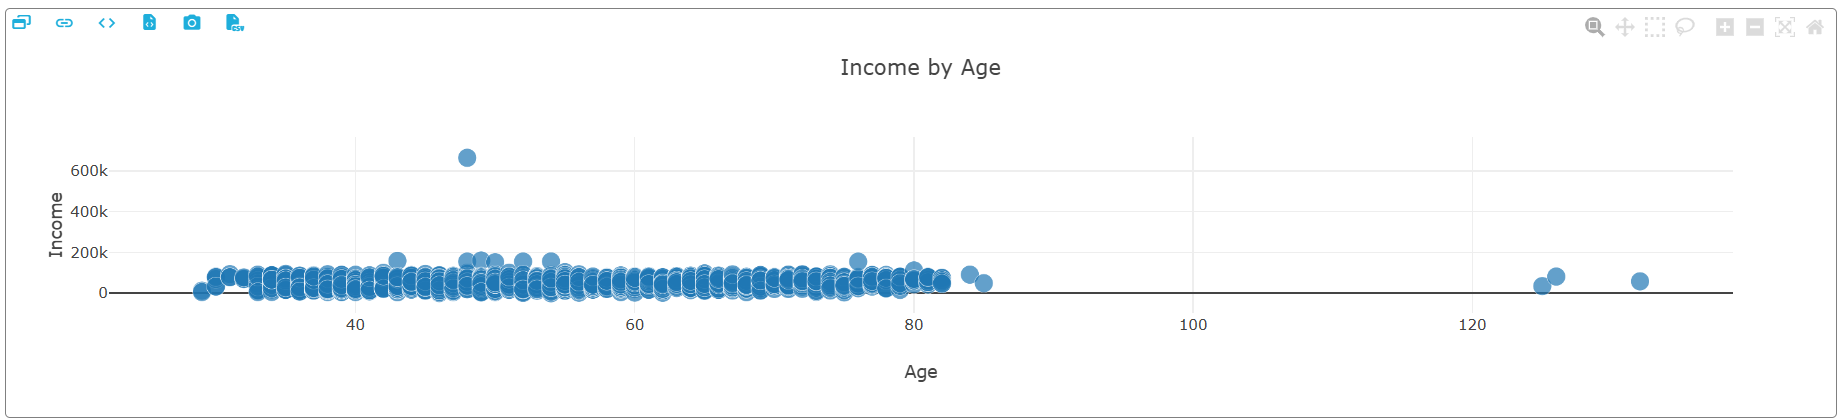

Biểu đồ scatter cho thấy phần lớn khách hàng nằm trong độ tuổi từ 30 đến 70, với thu nhập chủ yếu dưới 100,000. Dữ liệu phân tán rộng, không có xu hướng tuyến tính rõ rệt giữa tuổi và thu nhập. Một số ngoại lệ có thu nhập rất cao xuất hiện ở nhiều độ tuổi khác nhau.

**Nhận xét:**  

Tuổi không phải là yếu tố quyết định thu nhập trong tập dữ liệu này. Thu nhập cao có thể xuất hiện ở nhiều độ tuổi, nhưng phần lớn khách hàng trung niên có mức thu nhập trung bình. Cần loại bỏ ngoại lệ để phân tích chính xác hơn.

##### **Income vs Response - Khách hàng có phản hồi nhiều hơn ở mức thu nhập nào**

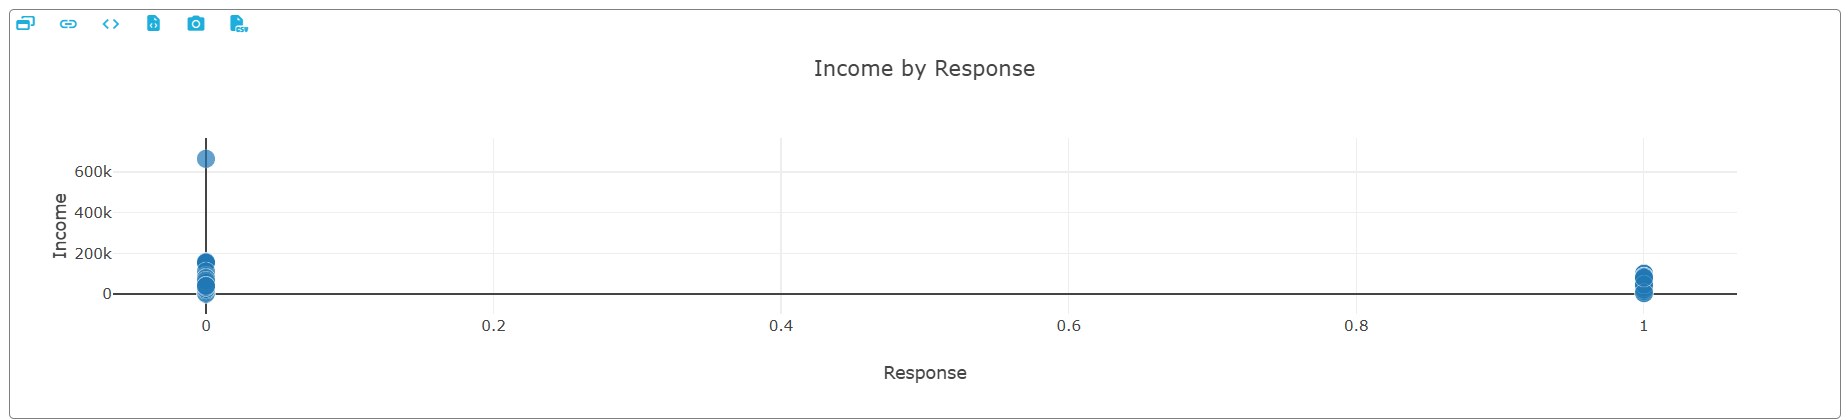

Biểu đồ scatter cho thấy phần lớn khách hàng không phản hồi (Response = 0), tập trung ở nhóm thu nhập dưới 100,000. Các khách hàng có phản hồi (Response = 1) cũng chủ yếu nằm trong khoảng thu nhập từ 40,000 đến 80,000, rất ít người phản hồi ở mức thu nhập quá thấp hoặc quá cao.

**Nhận xét:** 

Khách hàng có phản hồi thường thuộc nhóm thu nhập trung bình. Đây có thể là nhóm mục tiêu phù hợp cho các chiến dịch tiếp thị, trong khi nhóm thu nhập thấp và cao phản hồi ít hơn.

##### **Age vs Response - Nhóm tuổi nào phản hồi nhiều hơn**

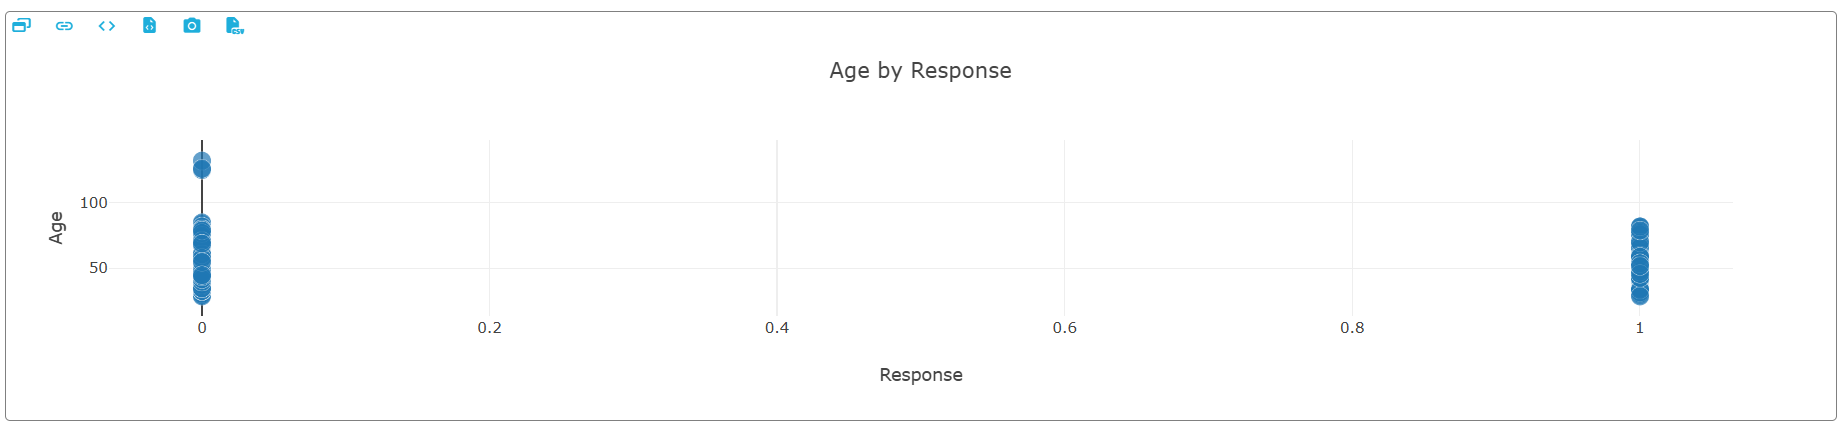

Biểu đồ scatter cho thấy phần lớn khách hàng không phản hồi (Response = 0), trải đều ở độ tuổi từ 30 đến 70. Nhóm khách hàng có phản hồi (Response = 1) cũng tập trung chủ yếu trong khoảng tuổi trung niên, đặc biệt từ 40 đến 60 tuổi.

**Nhận xét:** 

Khách hàng phản hồi thường thuộc nhóm tuổi trung niên. Đây có thể là nhóm có mức độ quan tâm cao hơn đến chiến dịch tiếp thị, phù hợp để doanh nghiệp tập trung khai thác.

##### **Income vs Education - Trình độ học vấn ảnh hưởng đến thu nhập ra sao**

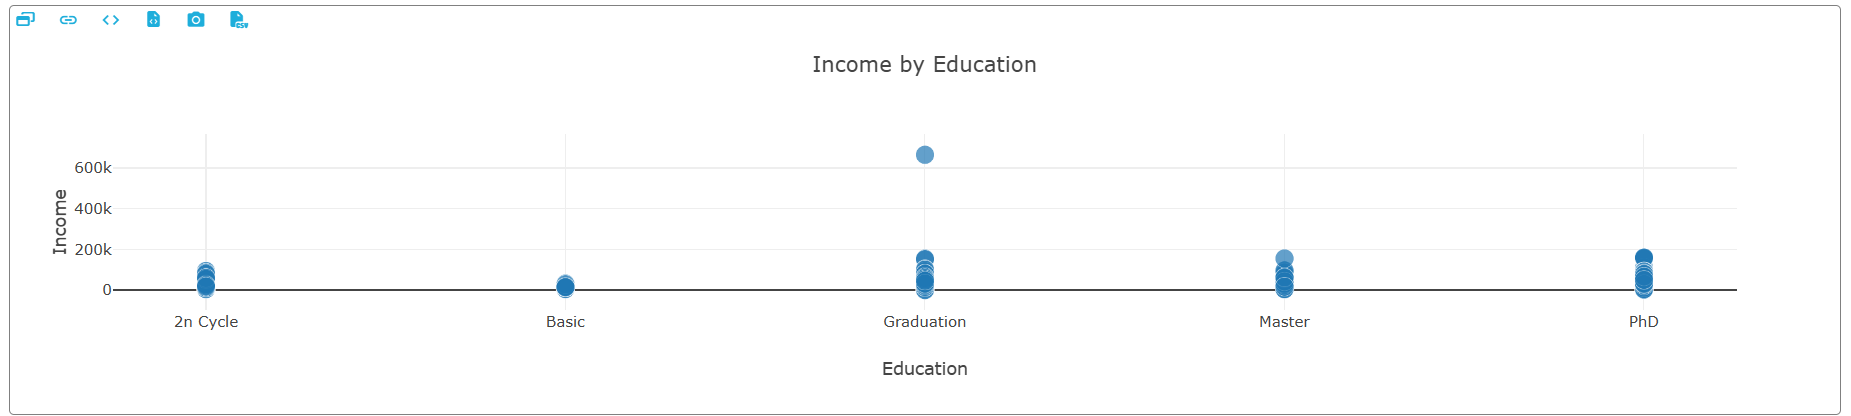

Biểu đồ scatter cho thấy thu nhập phân bố đa dạng trong từng nhóm học vấn. Nhóm Graduation có số lượng lớn nhất và mức thu nhập trải rộng, bao gồm cả các giá trị cao. Các nhóm PhD và Master cũng có xu hướng thu nhập cao hơn so với nhóm Basic và 2nd Cycle, vốn tập trung ở mức thu nhập thấp.

**Nhận xét:** 

Trình độ học vấn càng cao thì thu nhập có xu hướng tăng, đặc biệt ở nhóm Graduation, Master và PhD. Đây là yếu tố quan trọng ảnh hưởng đến khả năng chi tiêu và hành vi tiêu dùng của khách hàng.

##### **Age vs Education - Nhóm tuổi nào có trình độ học vấn cao hơn**

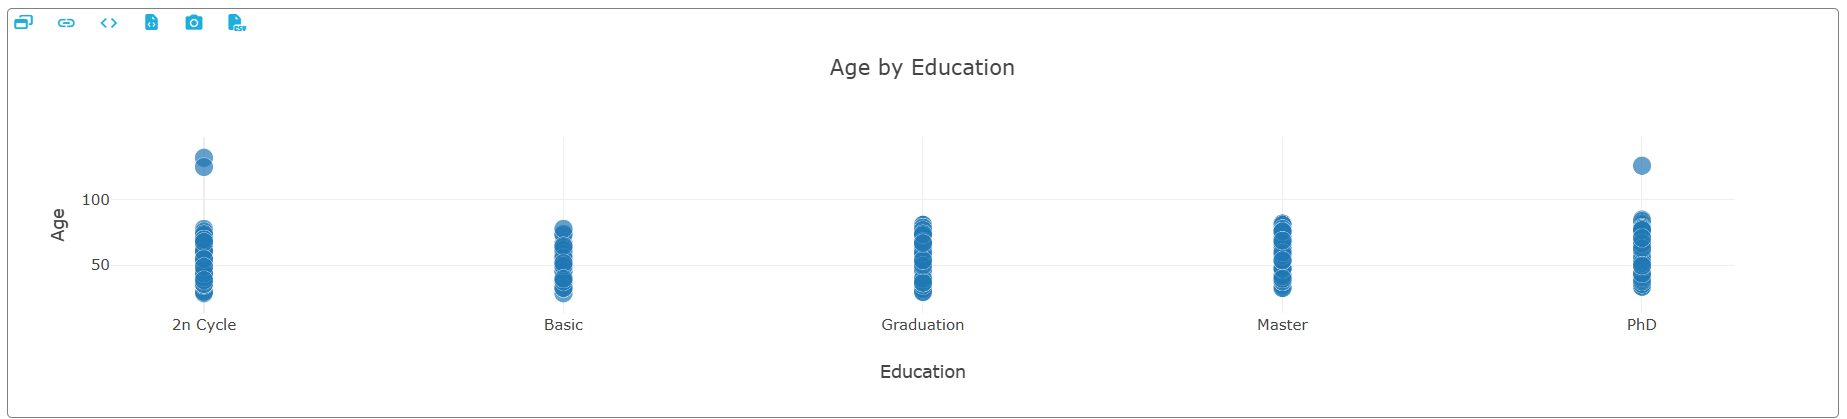

Biểu đồ scatter cho thấy các nhóm học vấn cao như Graduation, Master, và PhD tập trung chủ yếu ở độ tuổi từ 35 đến 65. Nhóm Basic và 2nd Cycle xuất hiện rải rác ở cả độ tuổi trẻ và lớn tuổi, nhưng số lượng ít hơn.

**Nhận xét:** 

Khách hàng có trình độ học vấn cao thường thuộc nhóm tuổi trung niên, cho thấy mối liên hệ giữa độ tuổi, quá trình học tập và khả năng tích lũy kiến thức. Đây là nhóm tiềm năng trong phân tích hành vi tiêu dùng.

#### **Kiểm tra tương quan giữa các biến số**

In [19]:
import pandas as pd

# Chỉ giữ các biến số để kiểm tra tương quan
# mã hóa biến Education thành số (Education_encoded)
corr_matrix = df[['Income', 'Age', 'Education_encoded', 'Response', 'Complain']].corr()

# Hiển thị kết quả
print(corr_matrix)

                     Income       Age  Education_encoded  Response  Complain
Income             1.000000  0.161791           0.120692  0.133047 -0.027225
Age                0.161791  1.000000           0.171065 -0.023692  0.030407
Education_encoded  0.120692  0.171065           1.000000  0.090806 -0.050863
Response           0.133047 -0.023692           0.090806  1.000000 -0.002029
Complain          -0.027225  0.030407          -0.050863 -0.002029  1.000000


**Phân tích tương quan giữa các biến số**

| Cặp biến                        | Hệ số tương quan | Nhận xét                                                                 |
|--------------------------------|------------------|-------------------------------------------------------------------------|
| Income vs Age                  | 0.162            | Có tương quan thuận nhẹ – người lớn tuổi có xu hướng thu nhập cao hơn |
| Income vs Education_encoded    | 0.127            | Có tương quan thuận nhẹ – trình độ học vấn cao hơn thường đi kèm thu nhập cao hơn |
| Income vs Response             | 0.133            | Có tương quan thuận nhẹ – người có thu nhập cao có xu hướng phản hồi nhiều hơn |
| Income vs Complain             | -0.027           | Tương quan rất yếu và âm – thu nhập không ảnh hưởng rõ rệt đến hành vi khiếu nại |
| Age vs Education_encoded       | 0.171            | Có tương quan thuận nhẹ – người lớn tuổi có xu hướng học vấn cao hơn |
| Age vs Response                | -0.024           | Tương quan rất yếu và âm – tuổi không ảnh hưởng rõ rệt đến phản hồi |
| Age vs Complain                | 0.030            | Tương quan rất yếu – tuổi không liên quan đáng kể đến hành vi khiếu nại |
| Education_encoded vs Response  | 0.091            | Tương quan yếu – học vấn có ảnh hưởng nhẹ đến phản hồi |
| Education_encoded vs Complain | -0.051           | Tương quan yếu và âm – học vấn cao hơn có thể ít khiếu nại hơn một chút |
| Response vs Complain           | ≈ 0.000          | Gần như không có tương quan – phản hồi và khiếu nại là hai hành vi độc lập |


**Tổng kết nhận xét:** 

Dựa trên bảng hệ số tương quan, ta nhận thấy rằng các biến số trong tập dữ liệu có mối liên hệ ở mức **rất nhẹ**, không có cặp nào thể hiện tương quan mạnh. Một số điểm nổi bật:

- **Income** có mối tương quan thuận nhẹ với `Age`, `Education_encoded`, và `Response`, cho thấy thu nhập có xu hướng tăng theo tuổi, học vấn và có liên hệ nhẹ với hành vi phản hồi.
- **Age** và `Education_encoded` có tương quan nhẹ, phản ánh xu hướng người lớn tuổi có học vấn cao hơn.
- Các mối liên hệ giữa **Complain** với các biến còn lại đều rất yếu, thậm chí gần như bằng 0, cho thấy hành vi khiếu nại không bị chi phối bởi nhân khẩu học như tuổi, học vấn hay thu nhập.
- **Response** có tương quan yếu với các biến còn lại, đặc biệt gần như không liên quan đến `Complain`, cho thấy phản hồi và khiếu nại là hai hành vi độc lập.

=> Tổng thể, các biến nhân khẩu học như tuổi, học vấn và thu nhập **chỉ ảnh hưởng nhẹ** đến hành vi phản hồi, và **không có ảnh hưởng rõ rệt** đến hành vi khiếu nại. Điều này gợi ý rằng để phân tích hành vi khách hàng chính xác hơn, cần kết hợp thêm các yếu tố khác như trải nghiệm dịch vụ, loại sản phẩm, hoặc mức độ tương tác thực tế.
